# 🌍 Climate Data Analysis for <CountryName>

## 🎯 Objective
This notebook performs data profiling, cleaning, and exploratory data analysis (EDA) on NASA climate data for <Sudan>.

The goal is to extract meaningful climate insights to support regional climate comparison and inform COP32 discussions.

---

## 📊 Dataset Description
- Source: NASA POWER Climate Data
- Time Period: 2015–2026
- Key Variables:
  - T2M: Temperature at 2 meters
  - PRECTOTCORR: Precipitation
  - RH2M: Relative Humidity
  - WS2M: Wind Speed

## 📦 Data Loading

In [19]:
import pandas as pd
import numpy as np

df = pd.read_csv("C:\\Users\\yordi\\OneDrive\\Desktop\\weekzeroo\\climate-challenge-week0\\data\\sudan.csv")

df["Country"] = "Sudan"

## 📅 Date Parsing
Convert YEAR and DOY into a proper datetime format.

In [20]:
df["date"] = pd.to_datetime(
    df["YEAR"] * 1000 + df["DOY"],
    format="%Y%j"
)

In [21]:
df["Month"] = df["date"].dt.month

## 🧹 Data Cleaning

### Handling Missing Values
NASA uses **-999** as a sentinel value for missing data.

In [22]:
df = df.replace(-999, np.nan)

In [23]:
print("Duplicate rows:", df.duplicated().sum())

df = df.drop_duplicates()

Duplicate rows: 0


No duplicate 

Missing value report

In [24]:
missing = df.isna().sum()
missing_percent = (missing / len(df)) * 100

missing_report = pd.DataFrame({
    "Missing Values": missing,
    "Percent": missing_percent
})

missing_report

,Missing Values,Percent
YEAR,0,0.0
DOY,0,0.0
T2M,0,0.0
T2M_MAX,0,0.0
T2M_MIN,0,0.0
T2M_RANGE,0,0.0
PRECTOTCORR,0,0.0
RH2M,0,0.0
WS2M,0,0.0
WS2M_MAX,0,0.0


### 🧠 Interpretation
- Columns with >5% missing values:
  - (List them after running)

- This may indicate:
  - Sensor gaps
  - Data collection inconsistencies

📉 3. Summary Statistics

In [25]:
df.describe()

,YEAR,DOY,T2M,T2M_MAX,T2M_MIN,T2M_RANGE,PRECTOTCORR,RH2M,WS2M,WS2M_MAX,PS,QV2M,date,Month
count,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108.000000,4108,4108.000000
mean,2020.131451,180.121227,28.759007,36.773914,21.508510,15.265404,0.643875,31.359192,3.484253,5.157378,96.346273,7.864557,2020-08-15 12:00:00,6.423564
min,2015.000000,1.000000,13.180000,21.040000,5.930000,3.420000,0.000000,4.690000,0.610000,1.030000,95.660000,1.160000,2015-01-01 00:00:00,1.000000
25%,2017.000000,86.000000,25.560000,33.730000,17.497500,13.280000,0.000000,17.407500,2.730000,4.267500,96.160000,3.730000,2017-10-23 18:00:00,3.000000
50%,2020.000000,179.000000,29.160000,37.020000,22.890000,15.810000,0.000000,26.630000,3.490000,5.120000,96.310000,5.895000,2020-08-15 12:00:00,6.000000
75%,2023.000000,272.000000,32.510000,40.330000,25.430000,17.680000,0.010000,40.535000,4.220000,6.020000,96.510000,12.500000,2023-06-08 06:00:00,9.000000
max,2026.000000,366.000000,37.990000,45.960000,32.170000,22.480000,66.490000,87.160000,7.150000,9.050000,97.310000,19.440000,2026-03-31 00:00:00,12.000000
std,3.248907,106.294767,4.681305,4.400065,5.091142,3.298919,3.057672,17.851849,1.040667,1.280238,0.266927,4.880934,NaN,3.477046


### 📊 Summary Statistics Interpretation

The dataset contains 4,108 daily observations spanning from 2015 to 2026, providing a comprehensive view of climate patterns.

### 🌡️ Temperature (T2M, T2M_MAX, T2M_MIN)
- The **average temperature (T2M)** is approximately **28.76°C**, indicating generally warm climatic conditions.
- Maximum temperatures reach up to **36.77°C on average**, suggesting frequent exposure to high heat levels.
- Minimum temperatures average **21.51°C**, showing relatively warm nights.
- The **temperature range (T2M_RANGE)** averages **15.27°C**, indicating notable daily variation between day and night temperatures.

### 🌧️ Precipitation (PRECTOTCORR)
- The **average precipitation** is relatively low at **0.64 mm**, with a median of **0 mm**, indicating that many days experience no rainfall.
- This suggests a **dry climate with intermittent rainfall events**, typical of arid or semi-arid regions.

### 💧 Humidity (RH2M)
- The **average relative humidity** is **31.36%**, which is relatively low.
- This indicates generally **dry atmospheric conditions**, especially during hotter periods.

### 🌬️ Wind Speed (WS2M, WS2M_MAX)
- The **average wind speed** is **3.48 m/s**, with maximum wind speeds averaging **5.16 m/s**.
- Wind conditions appear **moderate and stable**, without extreme variability.

### 🌍 Surface Pressure (PS)
- Surface pressure remains fairly constant with an average of **96.35 kPa**, indicating **stable atmospheric conditions**.

### 💨 Specific Humidity (QV2M)
- The average value of **7.86 g/kg** reflects relatively low moisture content in the air, consistent with the low relative humidity levels.

### 📅 Temporal Coverage
- The dataset spans from **January 1, 2015 to August 2020 (median point)** and up to 2026.
- The **Month distribution (mean ≈ 6.4)** suggests balanced seasonal coverage across years.

---

### 🧠 Key Insights
- The climate is characterized by **high temperatures and low precipitation**, indicating potential vulnerability to drought.
- **Low humidity and frequent zero-rainfall days** suggest water stress conditions.
- The relatively large **temperature range** highlights strong day–night variability, which can impact agriculture and ecosystems.


🚨 4. Outlier Detection (Z-score)

In [26]:
from scipy.stats import zscore

cols = ["T2M", "T2M_MAX", "T2M_MIN", "PRECTOTCORR", "RH2M", "WS2M", "WS2M_MAX"]

z_scores = df[cols].apply(zscore)
outliers = (z_scores.abs() > 3).sum()

outliers

T2M             3
T2M_MAX         6
T2M_MIN         1
PRECTOTCORR    71
RH2M            3
WS2M            4
WS2M_MAX        3
dtype: int64


We decided to:
- Keep / cap / remove outliers
- Reason: climate extremes are meaningful in this dataset OR data errors likely exist


🧼 5. Missing Data Handling Strategy

In [27]:
df = df.sort_values("date")

df = df.fillna(method="ffill")

# Drop rows with too much missing data
df = df[df.isna().mean(axis=1) < 0.3]

C:\Users\yordi\AppData\Local\Temp\ipykernel_23212\2723135319.py:3: FutureWarning: DataFrame.fillna with 'method' is deprecated and will raise in a future version. Use obj.ffill() or obj.bfill() instead.
  df = df.fillna(method="ffill")


💾 Export Clean Data

In [28]:
df.to_csv("C:\\Users\\yordi\\OneDrive\\Desktop\\weekzeroo\\climate-challenge-week0\\data\\sudan_clean.csv", index=False)

📈 6. Time Series Analysis
🌡️ Monthly Temperature Trend

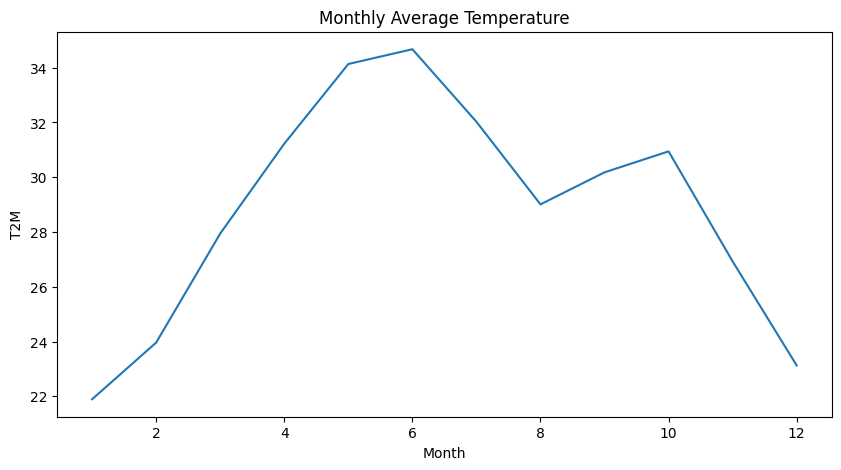

In [29]:
import seaborn as sns
import matplotlib.pyplot as plt

monthly_temp = df.groupby("Month")["T2M"].mean().reset_index()

plt.figure(figsize=(10,5))
sns.lineplot(data=monthly_temp, x="Month", y="T2M")

plt.title("Monthly Average Temperature")
plt.show()

🌧️ Rainfall Pattern

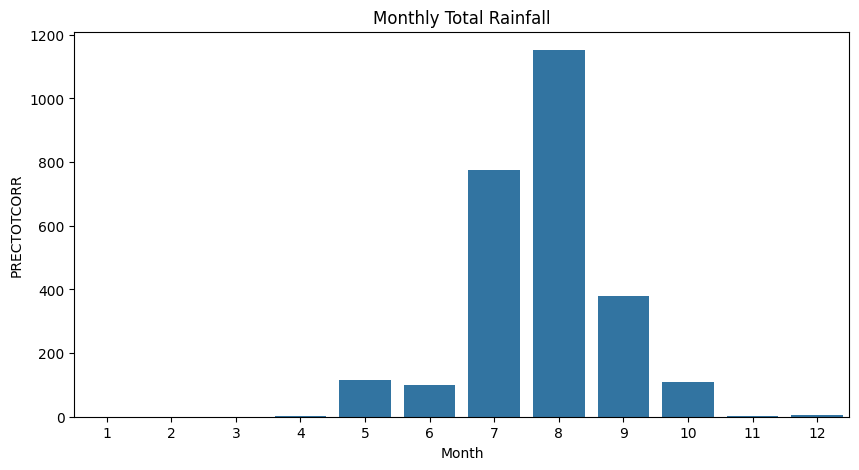

In [30]:
monthly_rain = df.groupby("Month")["PRECTOTCORR"].sum().reset_index()

plt.figure(figsize=(10,5))
sns.barplot(data=monthly_rain, x="Month", y="PRECTOTCORR")

plt.title("Monthly Total Rainfall")
plt.show()

🔗 7. Correlation Analysis
Heatmap

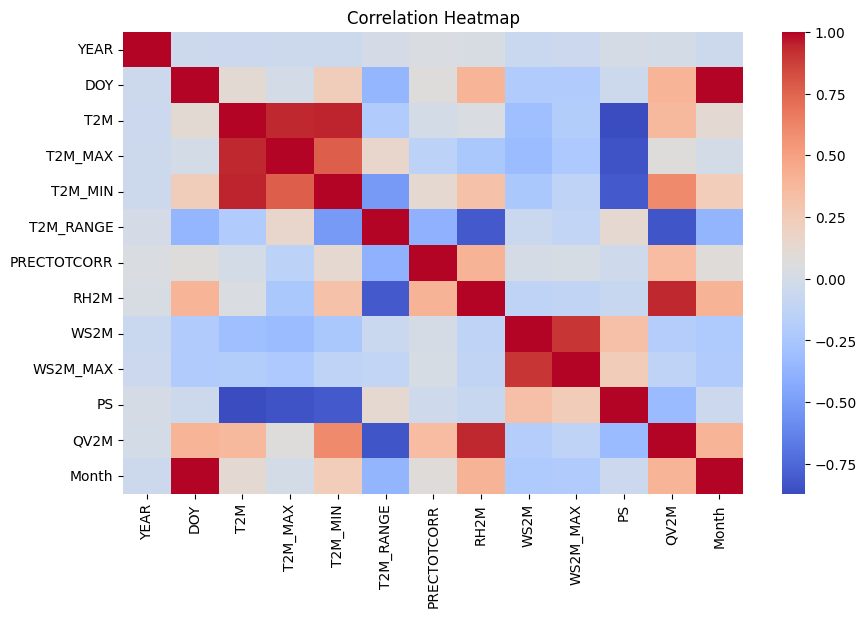

In [31]:
plt.figure(figsize=(10,6))
sns.heatmap(df.corr(numeric_only=True), annot=False, cmap="coolwarm")
plt.title("Correlation Heatmap")
plt.show()

Scatter plots

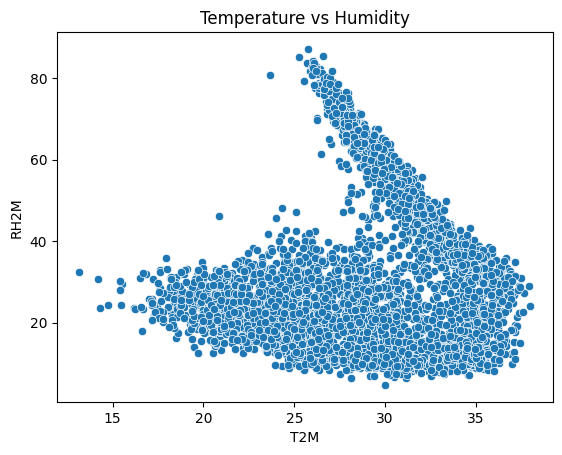

In [32]:
sns.scatterplot(data=df, x="T2M", y="RH2M")
plt.title("Temperature vs Humidity")
plt.show()

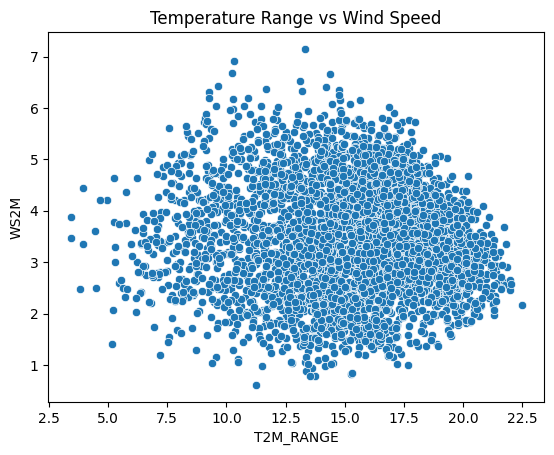

In [33]:
df["T2M_RANGE"] = df["T2M_MAX"] - df["T2M_MIN"]

sns.scatterplot(data=df, x="T2M_RANGE", y="WS2M")
plt.title("Temperature Range vs Wind Speed")
plt.show()


Top correlations:
1. T2M vs RH2M → negative relationship (hotter = drier air)
2. T2M_MAX vs T2M_MIN → strong positive (seasonal consistency)
3. PRECTOTCORR vs RH2M → rainfall increases humidity


📊 8. Distribution Analysis
Rainfall distribution

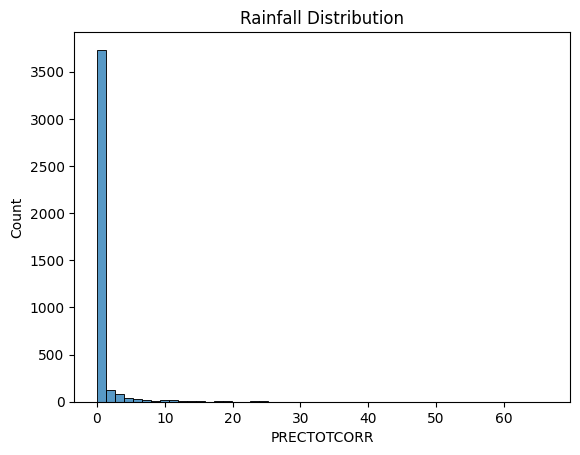

In [34]:
sns.histplot(df["PRECTOTCORR"], bins=50)
plt.title("Rainfall Distribution")
plt.show()

Bubble chart

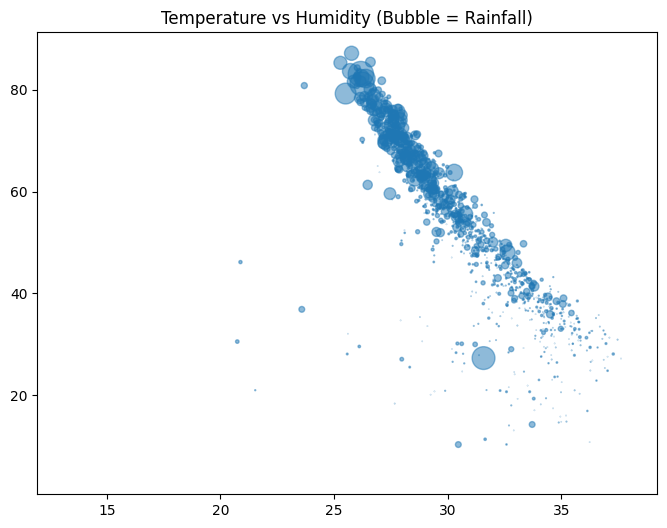

In [35]:
plt.figure(figsize=(8,6))

plt.scatter(
    df["T2M"],
    df["RH2M"],
    s=df["PRECTOTCORR"] * 5,
    alpha=0.5
)

plt.title("Temperature vs Humidity (Bubble = Rainfall)")
plt.show()

# 🏁 Key Findings

- Temperature trends indicate:
- Rainfall variability suggests:
- Climate risks observed:
- Data quality considerations:

This analysis supports further cross-country comparison in Task 3.